# Task 2 — 02 Baseline 0: Mean Face

**Goal.** Predict the mean training landmark vector for every image, in the original image resolution. This is the floor: the 0-component PCA shape model from **W09_L18** (the lecture explicitly states the mean is the rank-0 approximation of the shape model). Every later approach must materially beat it.

All preprocessing choices (grayscale, resize, normalisation) come from **W06_L12**; the mean-face baseline itself and inter-eye-normalised error come from **W09_L18**. We keep everything in the **original resolution** here so no scaling-back step is needed for the submission. Test landmarks do not exist — we never touch them.

Outputs:
- `models/mean_face.npy` — the mean landmark vector in original resolution.
- `results/baseline_metrics.json` — mean / median NME, per-landmark mean NME.
- `figures/ced_baseline.png` — CED on the val subset.
- `figures/baseline_examples.png` — 6 val examples (low / median / high error).


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR / 'src'))
from preprocess_img import load_data  # noqa: E402
from landmarks import nme, per_landmark_euclidean, ced_curve  # noqa: E402

FIG_DIR = NB_DIR / 'figures'
MODELS_DIR = NB_DIR / 'models'
RESULTS_DIR = NB_DIR / 'results'
for d in (FIG_DIR, MODELS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams['font.size'] = 11
plt.rcParams['savefig.dpi'] = 150

SEED = 42
np.random.seed(SEED)

## 1. Load data + split

Read everything via `data_layout.json` (produced by `01_explore.ipynb`) and the frozen `split_indices.npz`. No resize, no grayscale here — we predict in original pixel space.

In [2]:
data = load_data()
train_images = data['train_images']
train_points = data['train_points']
test_images = data['test_images']

split = np.load(NB_DIR / 'data' / 'split_indices.npz')
train_idx = split['train_idx']
val_idx = split['val_idx']

print(f'train_images: {train_images.shape} {train_images.dtype}')
print(f'train_points: {train_points.shape} {train_points.dtype}')
print(f'test_images:  {test_images.shape} {test_images.dtype}')
print(f'train split:  {train_idx.size} images')
print(f'val split:    {val_idx.size} images')

train_images: (2600, 256, 256, 3) uint8
train_points: (2600, 5, 2) float64
test_images:  (554, 256, 256, 3) uint8
train split:  2210 images
val split:    390 images


## 2. Compute the mean face

Mean over the **training subset only** (val is held out). All coordinates are in the original image resolution — the brief says submissions must be in original resolution and not reordered. Computing here in that frame removes one source of bugs.

In [3]:
train_subset_points = train_points[train_idx]
mean_face = np.nanmean(train_subset_points, axis=0)  # (5, 2)
print('mean_face (original resolution, x then y):')
for k, name in enumerate(['left_eye', 'right_eye', 'nose', 'left_mouth', 'right_mouth']):
    print(f'  {name:12s} ({mean_face[k, 0]:7.2f}, {mean_face[k, 1]:7.2f})')

np.save(MODELS_DIR / 'mean_face.npy', mean_face)
print('\nsaved', MODELS_DIR / 'mean_face.npy')

mean_face (original resolution, x then y):
  left_eye     (  79.86,  104.25)
  right_eye    ( 176.17,  103.14)
  nose         ( 128.38,  142.70)
  left_mouth   (  98.54,  177.06)
  right_mouth  ( 159.50,  176.15)

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/models/mean_face.npy


## 3. Evaluate on validation split

Predict the same `mean_face` for every val image. Compute the inter-eye-normalised mean error (NME, W09_L18).

In [4]:
val_true = train_points[val_idx]                       # (N_val, 5, 2)
val_pred = np.broadcast_to(mean_face, val_true.shape)  # tile (5, 2) over N_val

val_nmes = nme(val_pred, val_true)                     # (N_val,)
per_lm = per_landmark_euclidean(val_pred, val_true)    # (N_val, 5) pixel units
d_ie = np.linalg.norm(val_true[:, 0, :] - val_true[:, 1, :], axis=-1)  # (N_val,)
per_lm_nme = (per_lm / d_ie[:, None]).mean(axis=0)     # (5,) per-landmark mean NME

metrics = {
    'split': 'val (from 01_explore split_indices.npz)',
    'n_val': int(val_nmes.size),
    'mean_nme': float(np.nanmean(val_nmes)),
    'median_nme': float(np.nanmedian(val_nmes)),
    'per_landmark_mean_nme': per_lm_nme.tolist(),
    'landmark_order': ['left_eye', 'right_eye', 'nose', 'left_mouth', 'right_mouth'],
}
print(f'mean NME   = {metrics["mean_nme"]:.4f}')
print(f'median NME = {metrics["median_nme"]:.4f}')
print('per-landmark mean NME:')
for name, v in zip(metrics['landmark_order'], per_lm_nme):
    print(f'  {name:12s} {v:.4f}')

with open(RESULTS_DIR / 'baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nsaved', RESULTS_DIR / 'baseline_metrics.json')

mean NME   = 0.1246
median NME = 0.1117
per-landmark mean NME:
  left_eye     0.0978
  right_eye    0.0973
  nose         0.1544
  left_mouth   0.1368
  right_mouth  0.1366

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/baseline_metrics.json


## 4. CED curve (W09_L18)

Cumulative error distribution on the val split. x-axis: NME threshold; y-axis: fraction of images below that threshold.

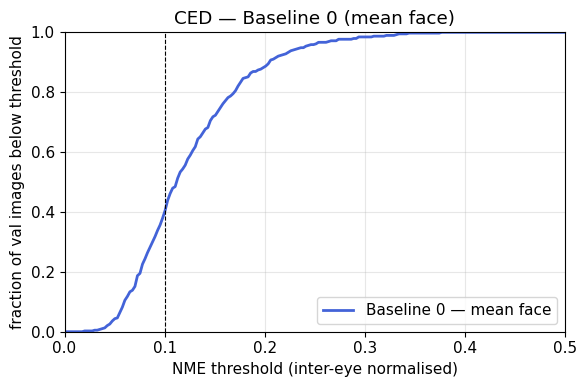

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/ced_baseline.png


In [5]:
thresholds, fractions = ced_curve(val_nmes, max_err=0.5, n=200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, fractions, color='#4363d8', lw=2, label='Baseline 0 — mean face')
ax.axvline(0.1, color='black', ls='--', lw=0.8)
ax.set_xlabel('NME threshold (inter-eye normalised)')
ax.set_ylabel('fraction of val images below threshold')
ax.set_title('CED — Baseline 0 (mean face)')
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'ced_baseline.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'ced_baseline.png')

## 5. Qualitative examples

Show two low-error, two median-error, and two high-error val images with predicted (red) and ground-truth (green) landmarks overlaid.

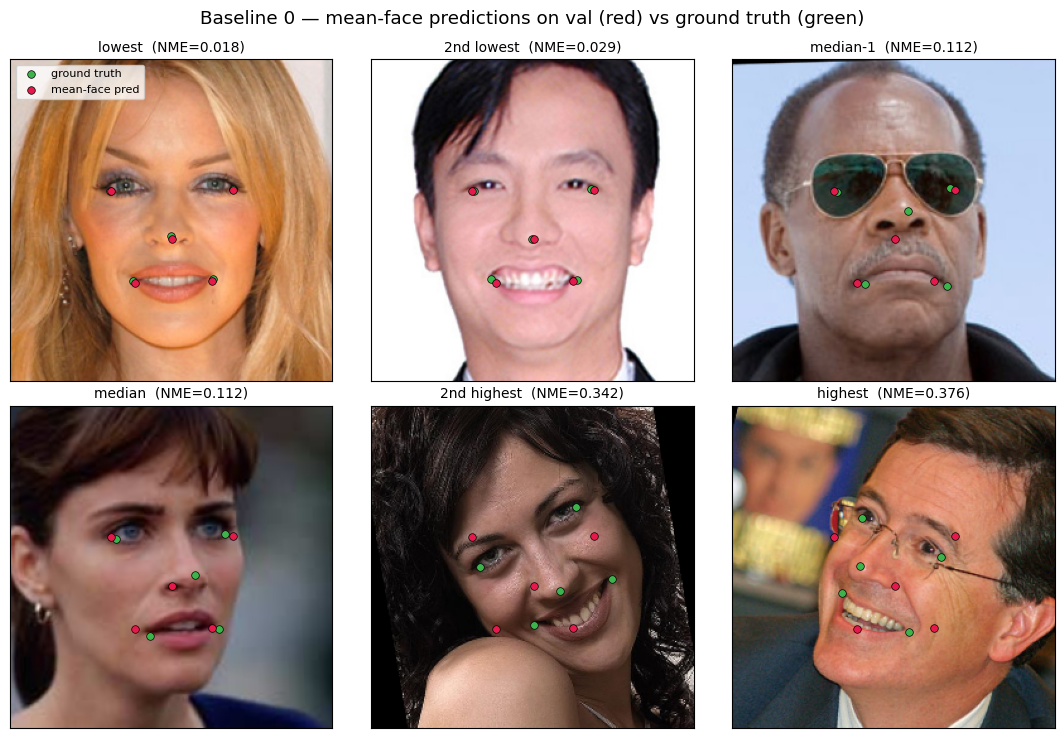

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/baseline_examples.png


In [6]:
order = np.argsort(val_nmes)
n = order.size
pick = [order[0], order[1], order[n // 2 - 1], order[n // 2], order[-2], order[-1]]
labels = ['lowest', '2nd lowest', 'median-1', 'median', '2nd highest', 'highest']

fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))
for ax, i, lab in zip(axes.ravel(), pick, labels):
    img = train_images[val_idx[i]]
    if img.ndim == 2 or (img.ndim == 3 and img.shape[-1] == 1):
        ax.imshow(np.squeeze(img), cmap='gray')
    else:
        ax.imshow(img.astype(np.uint8) if img.dtype != np.uint8 else img)
    gt = val_true[i]
    pr = mean_face
    ax.scatter(gt[:, 0], gt[:, 1], s=30, c='#3cb44b', edgecolors='black', linewidths=0.5, label='ground truth')
    ax.scatter(pr[:, 0], pr[:, 1], s=30, c='#e6194B', edgecolors='black', linewidths=0.5, label='mean-face pred')
    ax.set_title(f'{lab}  (NME={val_nmes[i]:.3f})', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].legend(loc='upper left', fontsize=8, framealpha=0.8)
fig.suptitle('Baseline 0 — mean-face predictions on val (red) vs ground truth (green)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'baseline_examples.png', bbox_inches='tight')
plt.show()
print('saved', FIG_DIR / 'baseline_examples.png')

## 6. Submission sanity check

Every test image gets the same mean-landmark vector. Predictions must be shape `(N_test, 5, 2)` in **original test-image resolution**. We do *not* save the submission here — that is `07`'s job.

In [7]:
N_test = test_images.shape[0]
test_pred = np.broadcast_to(mean_face, (N_test, 5, 2)).astype(np.float32)
print(f'test predictions shape={test_pred.shape}  dtype={test_pred.dtype}')
print(f'expected:           ({N_test}, 5, 2)')
assert test_pred.shape == (N_test, 5, 2)
print('OK — shape matches submission contract.')

test predictions shape=(554, 5, 2)  dtype=float32
expected:           (554, 5, 2)
OK — shape matches submission contract.


## 7. Summary

Baseline 0 predicts the mean training landmark vector for every image — the **rank-0 approximation of the PCA shape model** described in W09_L18. It uses no image features at all, so its error is exactly the population variance around the mean shape, normalised by inter-eye distance. This is the **floor**: every later approach (HOG + regression, CNN, cascaded regression) must materially improve over the mean and median NME above, otherwise the added complexity has no value.